In [1]:
#import Pkg; Pkg.add("Interpolations")

In [2]:
# TODO: rerun with EV saved — current results use V not EV for voting comparison
# qualitatively equivalent for conference, fix before submission
using Interpolations
using CairoMakie
using JLD2
using Statistics
using LaTeXStrings
# using GLMakie

include("src/ModelTypes.jl")
using ..ModelTypes

In [3]:

# load results
@load "../d/steady_states_2026-05-14_1327.jld2" results params policy_grid

# unpack grids
agrid = params.agrid
lgrid = params.lgrid
zgrid = params.zgrid

# baseline: no migration, yes redistribution
baseline = results[(0.0, 0.05*1)]

# pick a comparison
comp = results[(0.15, 0.0)]   # some migration, no redistribution

# welfare difference — collapse TFP dimension by averaging
V_base = dropdims(mean(baseline.V, dims=1), dims=1)   # (nl, na)
V_comp = dropdims(mean(comp.V, dims=1), dims=1)

diffs = V_base .- V_comp   # positive = prefers comp policy



7×100 Matrix{Float64}:
  0.272373    0.268441    0.264851    0.261437   …  -4.17454e-5  -0.000503586
  0.200663    0.198615    0.196679    0.194757      -0.00186721  -0.00219465
  0.131372    0.130447    0.129514    0.128538      -0.00426814  -0.00442015
  0.0698217   0.0694038   0.0689556   0.0684886     -0.00712236  -0.0070641
  0.0139575   0.0137881   0.0136121   0.0134332     -0.0104138   -0.0100937
 -0.0376068  -0.037593   -0.0375777  -0.0375656  …  -0.0141091   -0.0134325
 -0.0822722  -0.0821405  -0.0819985  -0.0818386     -0.0177679   -0.0166635

In [4]:
# for each labor state, find the asset threshold
# (highest asset level where household still votes for comp)

nl = length(lgrid); na = length(agrid);

votes = diffs .> 0.0;

votes

display(lgrid)
display(agrid[60])

7-element Vector{Float64}:
 0.5975005946182375
 0.7094017049096536
 0.842259879674708
 1.0
 1.1872820065776057
 1.4096385631429458
 1.6736385017975295

14.649287026270075

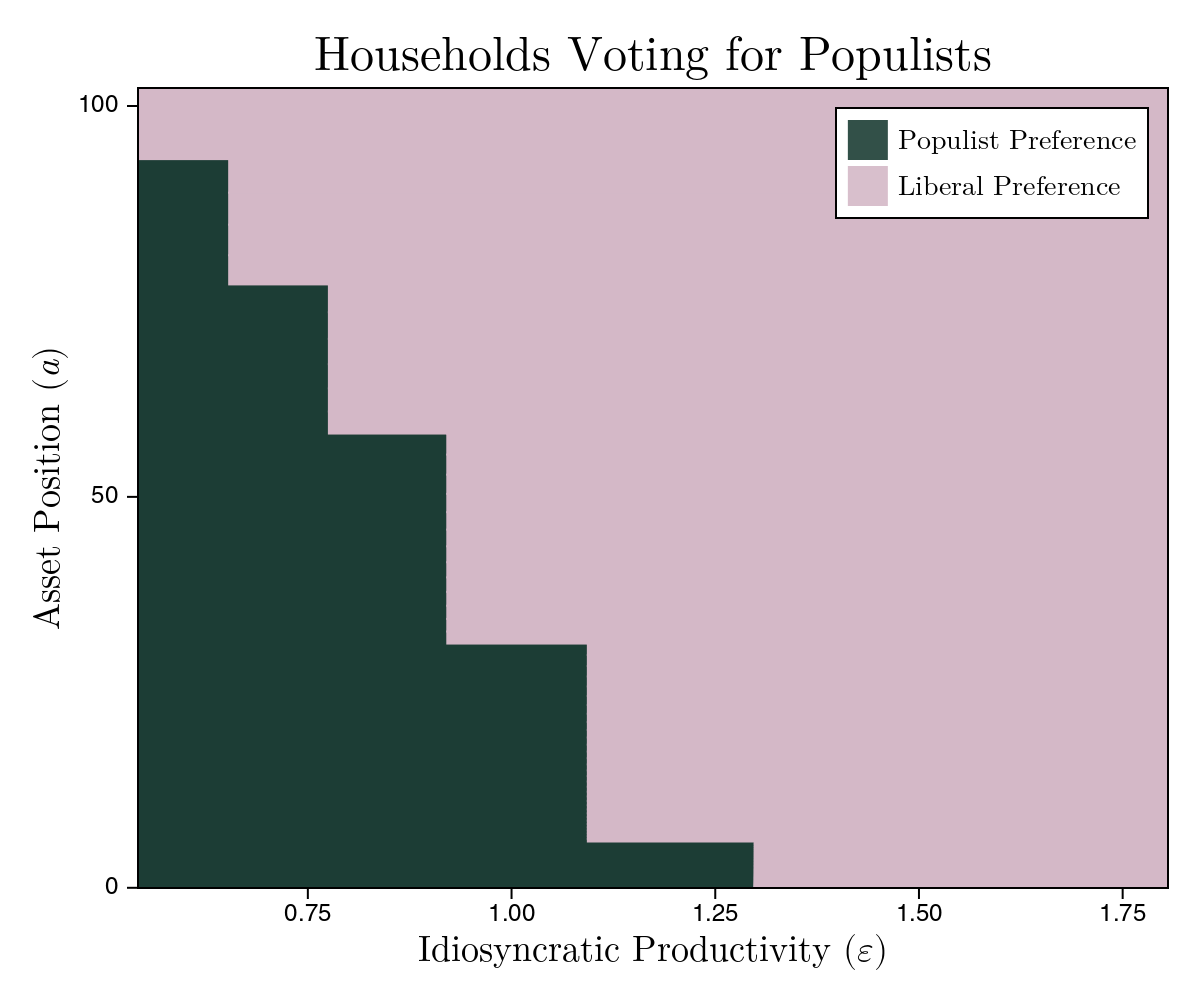

In [5]:
set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title  = L"\text{Households Voting for Populists}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid, (diffs .> 0.0),
    colormap = [("#D4B8C7"), ("#1C3D35")])

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Populist Preference}", L"\text{Liberal Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_baseline2_small.pdf", fig)
fig

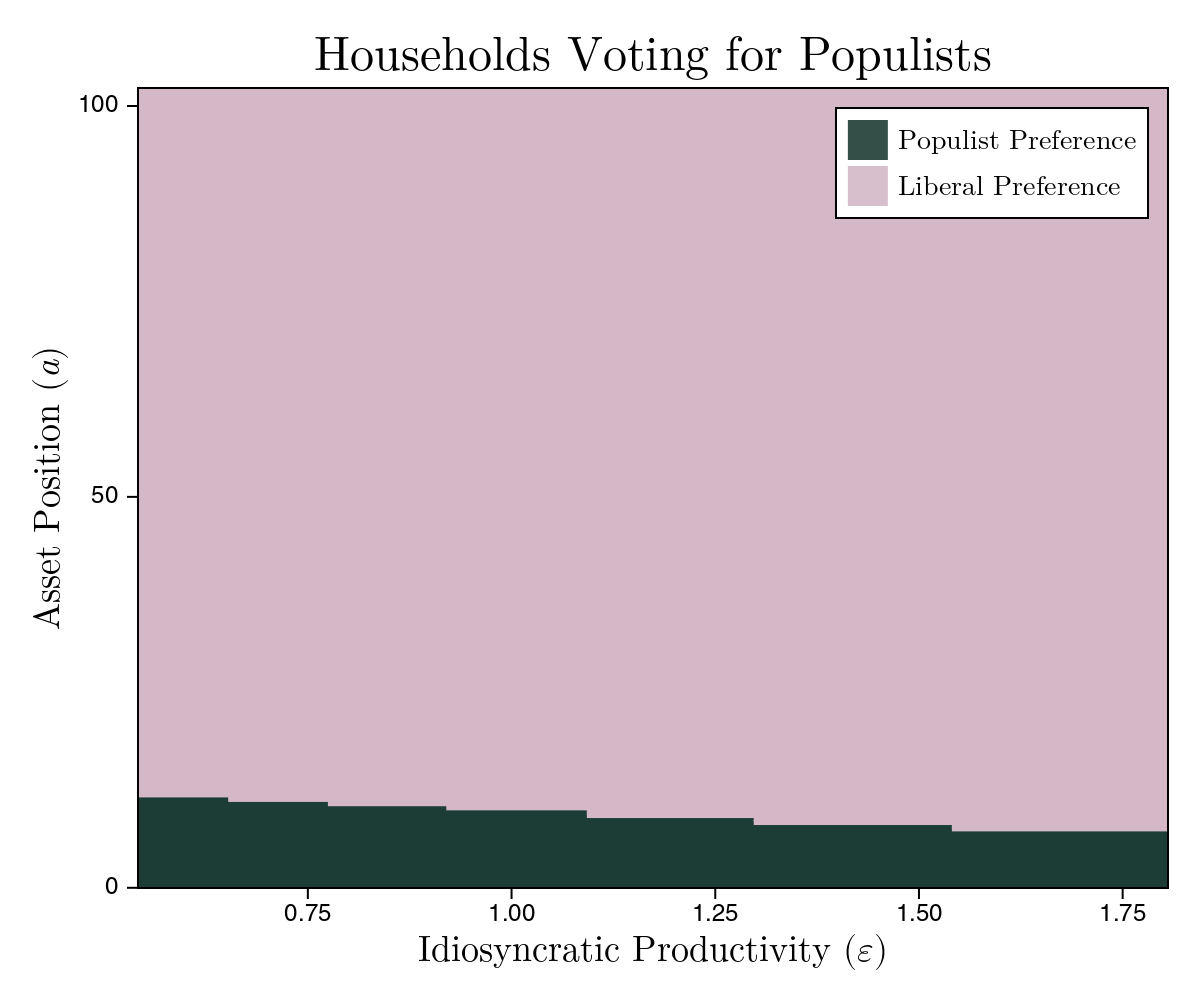

In [10]:
# baseline: no migration, yes redistribution
baseline = results[(0.0, 0)]

# pick a comparison
comp = results[(0.15, 0.0)]   # some migration, no redistribution

# welfare difference — collapse TFP dimension by averaging
V_base = dropdims(mean(baseline.V, dims=1), dims=1)   # (nl, na)
V_comp = dropdims(mean(comp.V, dims=1), dims=1)

diffs = V_base .- V_comp   # positive = prefers comp policy

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title  = L"\text{Households Voting for Populists}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid, (diffs .> 0.0),
    colormap = [("#D4B8C7"), ("#1C3D35")])

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Populist Preference}", L"\text{Liberal Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_baseline3_small.pdf", fig)
fig

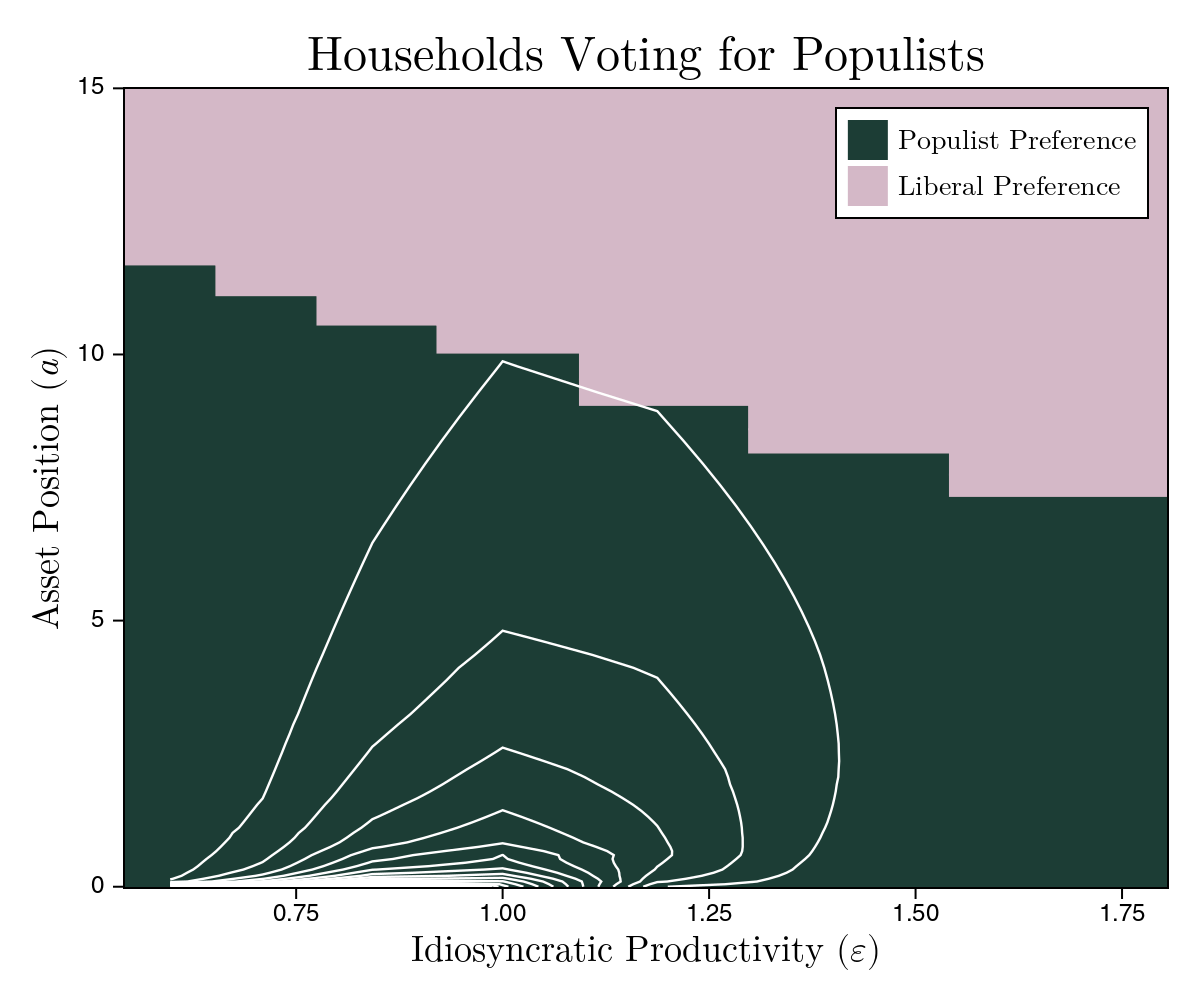

In [13]:
# first collapse the TFP dimension of μ — sum over it states
# μ is (nt, nl, nmu) — sum over first dimension
amu = range(minimum(agrid), maximum(agrid), length(agrid)*10)
μ_collapsed = dropdims(sum(comp.μ, dims=1), dims=1)   # (nl, nmu)

# amu is the distribution grid, lgrid is labor grid
# need to make sure dimensions match your diffs which is on agrid not amu
# interpolate μ onto agrid for consistency
μ_on_agrid = zeros(nl, na)
for il in 1:nl
    itp = LinearInterpolation(amu, μ_collapsed[il, :], extrapolation_bc=Flat())
    μ_on_agrid[il, :] = itp.(agrid[1:na])
end

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"Idiosyncratic Productivity $(\varepsilon)$",
    ylabel = L"Asset Position $(a)$",
    title  = L"\text{Households Voting for Populists}",
    titlesize = 24, xlabelsize = 18, ylabelsize = 18)

# voting heatmap
heatmap!(ax, lgrid, agrid[1:60], (diffs[:,1:60] .> 0.0),
    colormap = [ "#D4B8C7","#1C3D35"])

# distribution contours on top
contour!(ax, lgrid, agrid[1:60], μ_on_agrid[:,1:60],
    levels = 30,
    color = :white,
    linewidth = 1.2,
    alpha = 0.7)

elem1 = PolyElement(color="#1C3D35")
elem2 = PolyElement(color="#D4B8C7")
Legend(fig[1,1], [elem1, elem2], [L"\text{Populist Preference}", L"\text{Liberal Preference}"],
    tellwidth=false, tellheight=false,
    halign=:right, valign=:top, margin=(10,10,10,10))

save("voting_with_distribution_small.pdf", fig)
fig

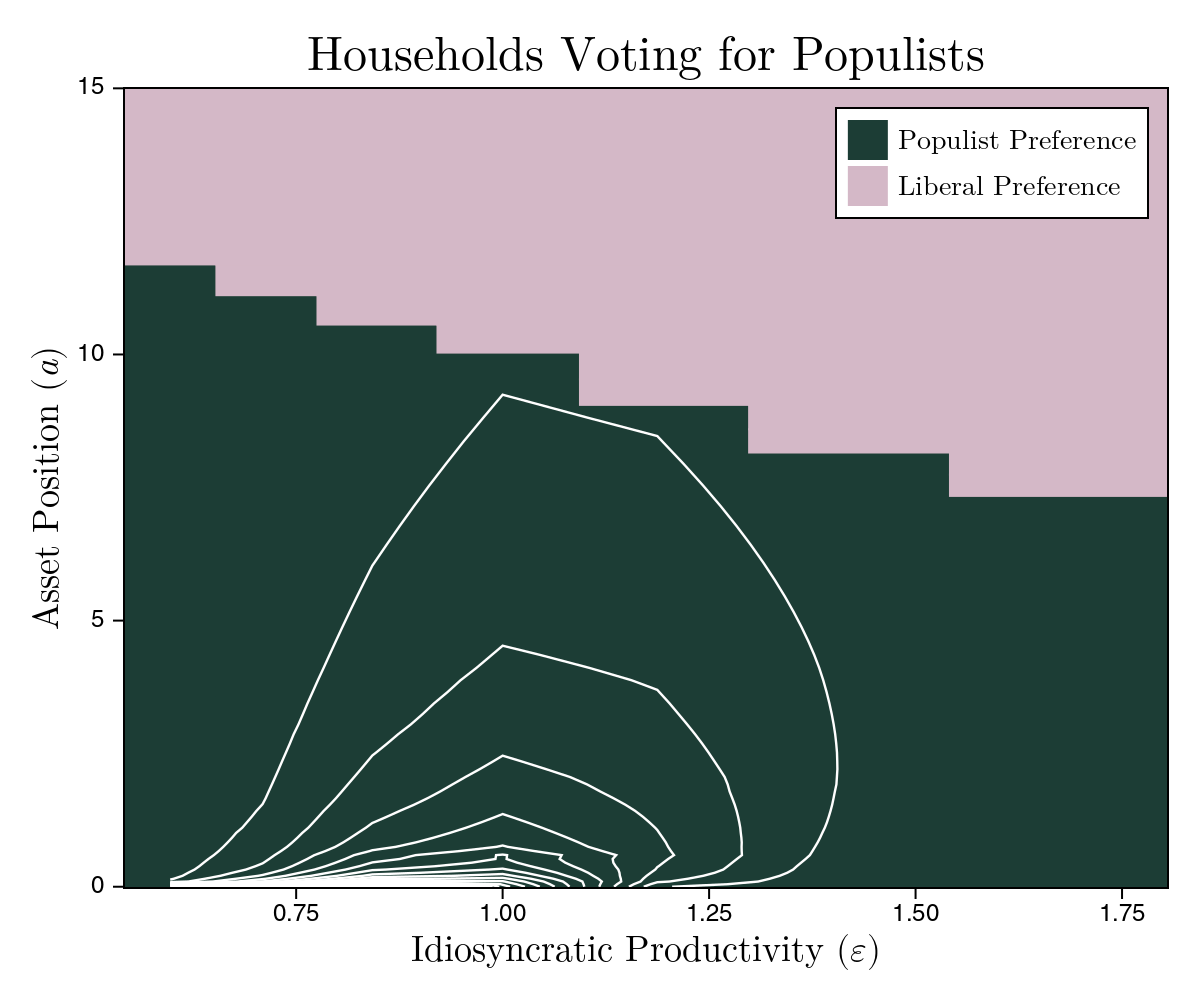

In [15]:
# first collapse the TFP dimension of μ — sum over it states
# μ is (nt, nl, nmu) — sum over first dimension
amu = range(minimum(agrid), maximum(agrid), length(agrid)*10)
μ_collapsed = dropdims(sum(baseline.μ, dims=1), dims=1)   # (nl, nmu)

# amu is the distribution grid, lgrid is labor grid
# need to make sure dimensions match your diffs which is on agrid not amu
# interpolate μ onto agrid for consistency
μ_on_agrid = zeros(nl, na)
for il in 1:nl
    itp = LinearInterpolation(amu, μ_collapsed[il, :], extrapolation_bc=Flat())
    μ_on_agrid[il, :] = itp.(agrid[1:na])
end

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"Idiosyncratic Productivity $(\varepsilon)$",
    ylabel = L"Asset Position $(a)$",
    title  = L"\text{Households Voting for Populists}",
    titlesize = 24, xlabelsize = 18, ylabelsize = 18)

# voting heatmap
heatmap!(ax, lgrid, agrid[1:60], (diffs[:,1:60] .> 0.0),
    colormap = ["#D4B8C7","#1C3D35"])

# distribution contours on top
contour!(ax, lgrid, agrid[1:60], μ_on_agrid[:,1:60],
    levels = 30,
    color = :white,
    linewidth = 1.2,
    alpha = 0.7)

elem1 = PolyElement(color="#1C3D35")
elem2 = PolyElement(color="#D4B8C7")
Legend(fig[1,1], [elem1, elem2], [L"\text{Populist Preference}", L"\text{Liberal Preference}"],
    tellwidth=false, tellheight=false,
    halign=:right, valign=:top, margin=(10,10,10,10))

save("voting_with_distribution_2_small.pdf", fig)
fig

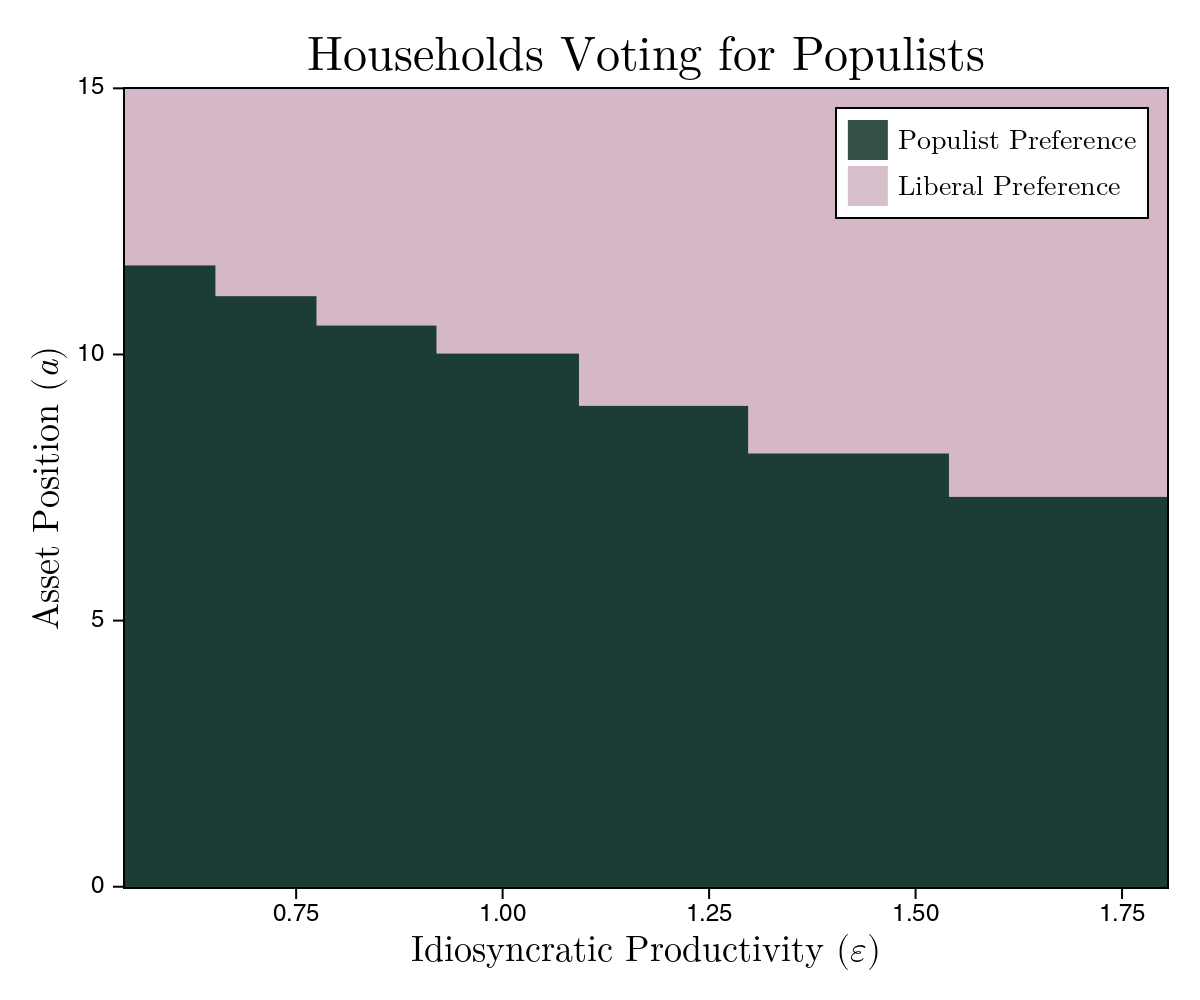

In [22]:
# baseline: no migration, yes redistribution
baseline = results[(0.0, 0.0)]

# pick a comparison
comp = results[(0.05, 0.0)]   # some migration, no redistribution

# welfare difference — collapse TFP dimension by averaging
V_base = dropdims(mean(baseline.V, dims=1), dims=1)   # (nl, na)
V_comp = dropdims(mean(comp.V, dims=1), dims=1)

diffs = V_base .- V_comp   # positive = prefers comp policy

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title  = L"\text{Households Voting for Populists}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid[1:60], (diffs[:,1:60] .> 0.0),
    colormap = [("#D4B8C7"), ("#1C3D35")])

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Populist Preference}", L"\text{Liberal Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_migration_baseline.pdf", fig)
fig

In [46]:
# baseline: no migration, yes redistribution
baseline = results[(0.0, 0.0)]

# pick a comparison
comp = results[(0.25, 0.0)]   # some migration, no redistribution

# welfare difference — collapse TFP dimension by averaging
V_base = dropdims(mean(baseline.V, dims=1), dims=1)   # (nl, na)
V_comp = dropdims(mean(comp.V, dims=1), dims=1)

diffs = V_base .- V_comp   # positive = prefers comp policy

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title  = L"\text{Households Voting for Populists}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid[1:60], (diffs[:,1:60] .> 0.0),
    colormap = [("#D4B8C7"), ("#1C3D35")])



elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Populist Preference}", L"\text{Liberal Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_migration_increase.pdf", fig)
fig

# vote share for populism comparing baseline to comp
# diffs is (nl, na) — positive means prefers populism

# voting decision
votes_populist = diffs .> 0.0   # (nl, na) boolean

# μ_on_agrid is (nl, na) — mass at each (labor, asset) point
# vote share = sum of mass where household votes populist
vote_share = sum(μ_on_agrid .* votes_populist)

@printf("Populist vote share: %.4f\n", vote_share)
@printf("Liberal vote share:  %.4f\n", 1 - vote_share)

Populist vote share: 0.5757
Liberal vote share:  0.4243


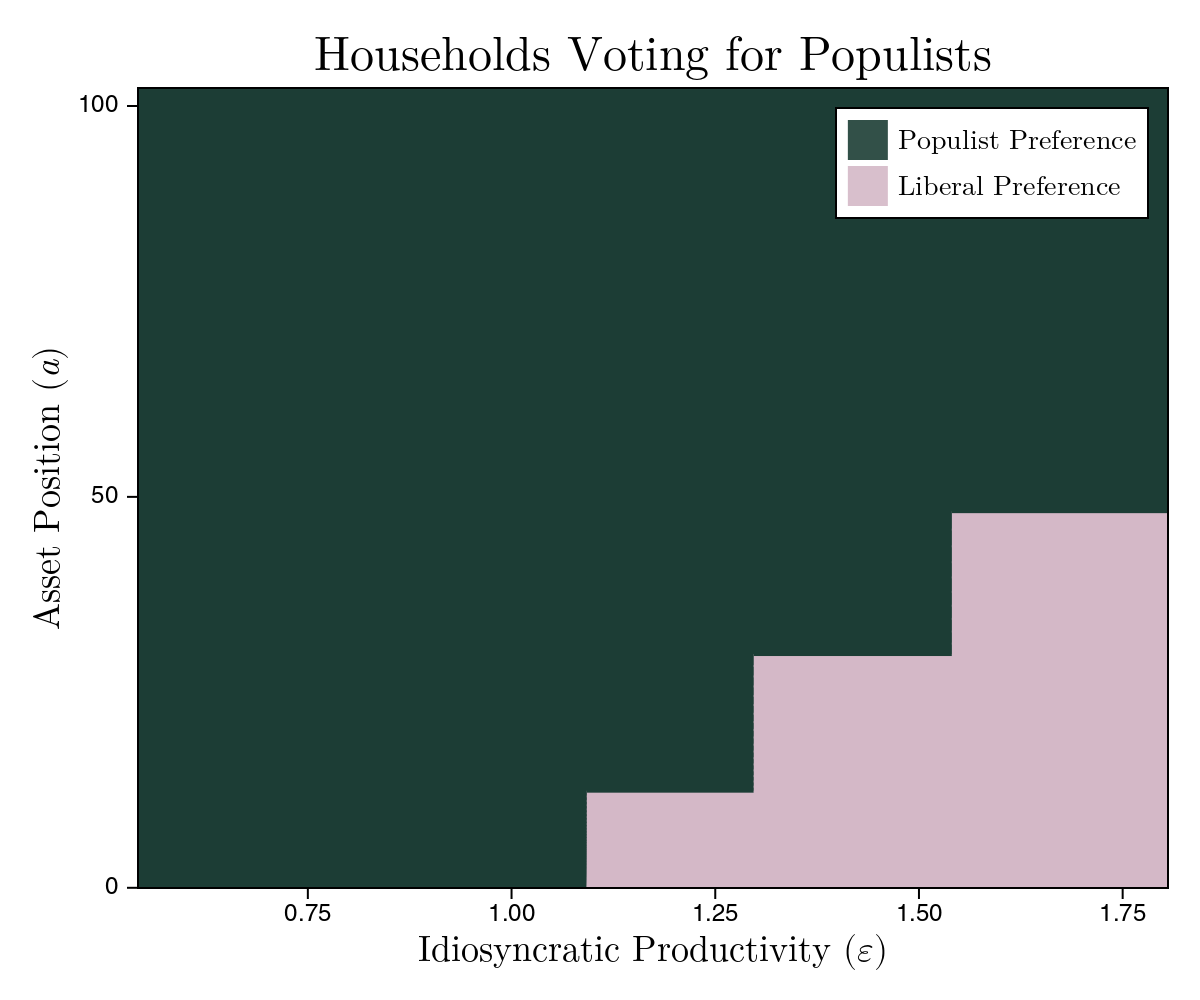

In [33]:
# baseline: no migration, yes redistribution
baseline = results[(0.0, 0.05)]

# pick a comparison
comp = results[(0.0, 0.0)]   # some migration, no redistribution

# welfare difference — collapse TFP dimension by averaging
V_base = dropdims(mean(baseline.V, dims=1), dims=1)   # (nl, na)
V_comp = dropdims(mean(comp.V, dims=1), dims=1)

diffs = V_base .- V_comp   # positive = prefers comp policy

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title  = L"\text{Households Voting for Populists}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid, (diffs .> 0.0),
    colormap = [("#D4B8C7"), ("#1C3D35")])

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Populist Preference}", L"\text{Liberal Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_baseline_redist.pdf", fig)
fig

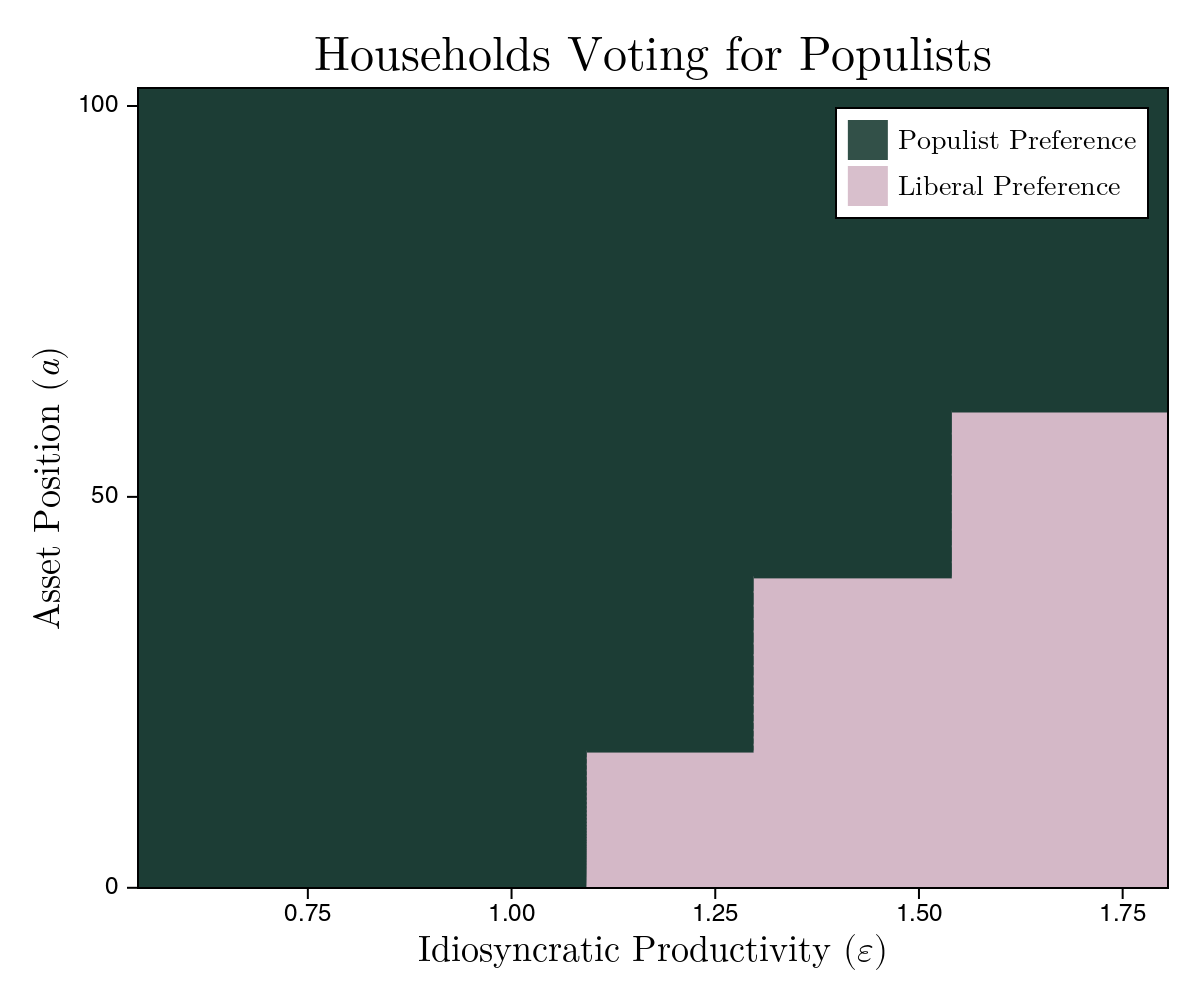

In [36]:
# baseline: no migration, yes redistribution
baseline = results[(0.0, 0.5)]

# pick a comparison
comp = results[(0.0, 0.0)]   # some migration, no redistribution

# welfare difference — collapse TFP dimension by averaging
V_base = dropdims(mean(baseline.V, dims=1), dims=1)   # (nl, na)
V_comp = dropdims(mean(comp.V, dims=1), dims=1)

diffs = V_base .- V_comp   # positive = prefers comp policy

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title  = L"\text{Households Voting for Populists}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid, (diffs .> 0.0),
    colormap = [("#D4B8C7"), ("#1C3D35")])

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Populist Preference}", L"\text{Liberal Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_increase_redist.pdf", fig)
fig

Populist vote share: 0.5765
Liberal vote share:  0.4235


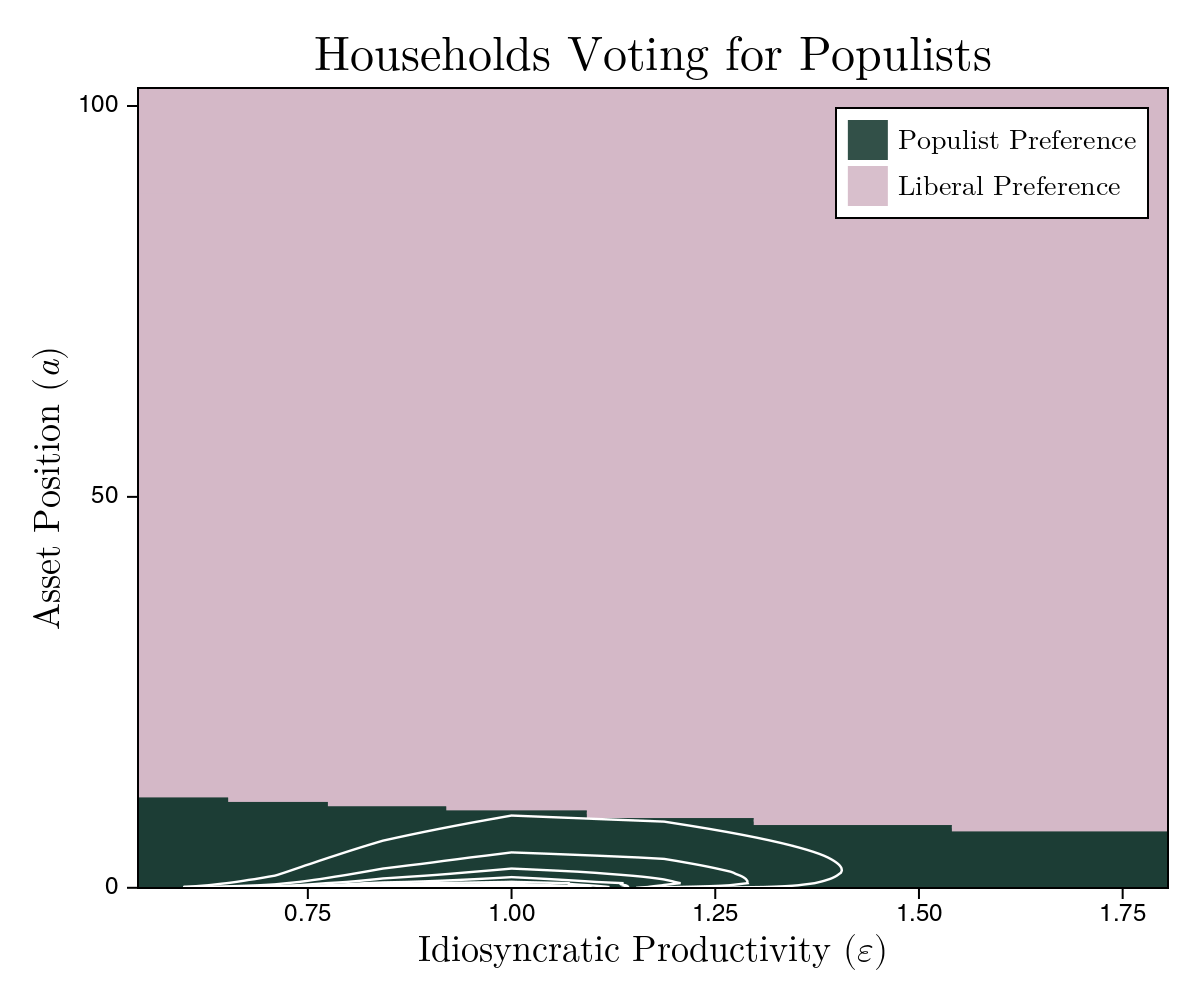

In [56]:
# baseline: no migration, yes redistribution
using Printf
baseline = results[(0.0, 0.0)]

# pick a comparison
comp = results[(0.15, 0.0)]   # some migration, no redistribution

# welfare difference — collapse TFP dimension by averaging
V_base = dropdims(mean(baseline.V, dims=1), dims=1)   # (nl, na)
V_comp = dropdims(mean(comp.V, dims=1), dims=1)

diffs = V_base .- V_comp   # positive = prefers comp policy

# vote share for populism comparing baseline to comp
# diffs is (nl, na) — positive means prefers populism

# voting decision
votes_populist = diffs .> 0.0   # (nl, na) boolean

# μ_on_agrid is (nl, na) — mass at each (labor, asset) point
# vote share = sum of mass where household votes populist
vote_share = sum(μ_on_agrid .* votes_populist)

@printf("Populist vote share: %.4f\n", vote_share)
@printf("Liberal vote share:  %.4f\n", 1 - vote_share)

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title  = L"\text{Households Voting for Populists}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid, (diffs .> 0.0),
    colormap = [("#D4B8C7"), ("#1C3D35")])

μ_collapsed = dropdims(sum(baseline.μ, dims=1), dims=1)   # (nl, nmu)

# amu is the distribution grid, lgrid is labor grid
# need to make sure dimensions match your diffs which is on agrid not amu
# interpolate μ onto agrid for consistency
μ_on_agrid = zeros(nl, na)
for il in 1:nl
    itp = LinearInterpolation(amu, μ_collapsed[il, :], extrapolation_bc=Flat())
    μ_on_agrid[il, :] = itp.(agrid[1:na])
end

# distribution contours on top
contour!(ax, lgrid, agrid[1:60], μ_on_agrid[:,1:60],
    levels = 30,
    color = :white,
    linewidth = 1.2,
    alpha = 0.7)

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Populist Preference}", L"\text{Liberal Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_mig_redist.pdf", fig)
fig



Populist vote share: 0.1408
Liberal vote share:  0.8592


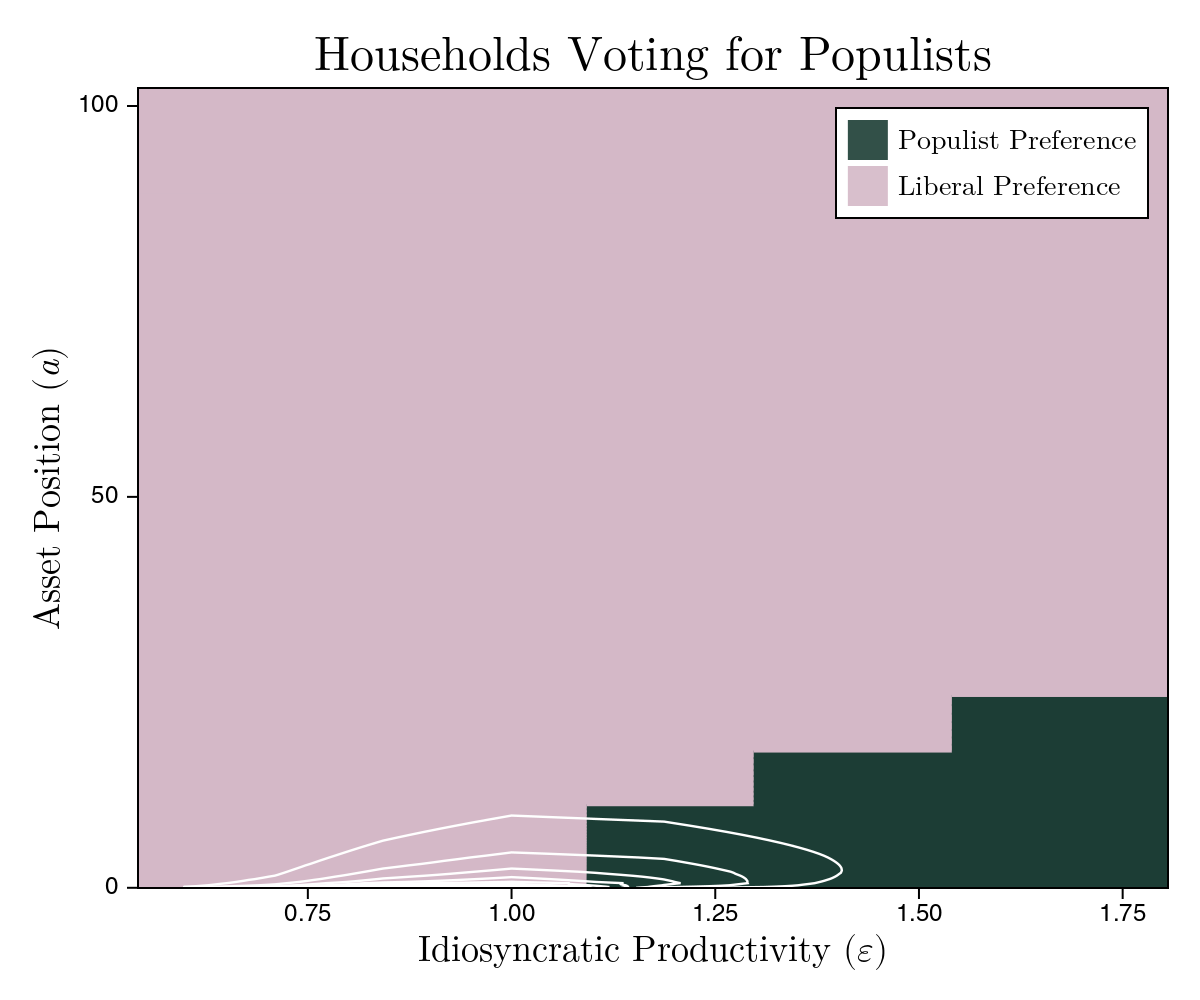

In [57]:
# baseline: no migration, yes redistribution
baseline = results[(0.0, 0.00)]

# pick a comparison
comp = results[(0.15, 0.05)]   # some migration, no redistribution

# welfare difference — collapse TFP dimension by averaging
V_base = dropdims(mean(baseline.V, dims=1), dims=1)   # (nl, na)
V_comp = dropdims(mean(comp.V, dims=1), dims=1)

diffs = V_base .- V_comp   # positive = prefers comp policy

# vote share for populism comparing baseline to comp
# diffs is (nl, na) — positive means prefers populism

# voting decision
votes_populist = diffs .> 0.0   # (nl, na) boolean

# μ_on_agrid is (nl, na) — mass at each (labor, asset) point
# vote share = sum of mass where household votes populist
vote_share = sum(μ_on_agrid .* votes_populist)

@printf("Populist vote share: %.4f\n", vote_share)
@printf("Liberal vote share:  %.4f\n", 1 - vote_share)

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title  = L"\text{Households Voting for Populists}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid, (diffs .> 0.0),
    colormap = [("#D4B8C7"), ("#1C3D35")])

μ_collapsed = dropdims(sum(baseline.μ, dims=1), dims=1)   # (nl, nmu)

# amu is the distribution grid, lgrid is labor grid
# need to make sure dimensions match your diffs which is on agrid not amu
# interpolate μ onto agrid for consistency
μ_on_agrid = zeros(nl, na)
for il in 1:nl
    itp = LinearInterpolation(amu, μ_collapsed[il, :], extrapolation_bc=Flat())
    μ_on_agrid[il, :] = itp.(agrid[1:na])
end

# distribution contours on top
contour!(ax, lgrid, agrid[1:60], μ_on_agrid[:,1:60],
    levels = 30,
    color = :white,
    linewidth = 1.2,
    alpha = 0.7)

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Populist Preference}", L"\text{Liberal Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_mig_redist2.pdf", fig)
fig